In [ ]:
!pip install roboflow
!pip install ultralytics
!pip install supervision

In [18]:
from roboflow import Roboflow
rf = Roboflow(api_key="3ZpBoTDloPfMkdjc1mFq")
project = rf.workspace("shreya-sarpal").project("coca-cola-products-bumea")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Coca-Cola-Products-1 in yolov11:: 100%|██████████| 440/440 [00:00<00:00, 8761.07it/s]


In [19]:
# Afinar modelo

from ultralytics import YOLO,YOLOWorld

# 1. Cargar el modelo (nano, el más pequeño)
# tiempo: alrededor de 25m
#--n # muy rápido pero poco preciso
#--m # mucha mejor detección
#--s # mejor balance
model = YOLO("yolo11m.pt")
# tiempo: alredor de 5m
#model = YOLO("yolo26n.pt") #no se detecto nada, pendiente entrenar mas epocs
# tiempo: 4m05s
#model= YOLOWorld("/content/yolov8s-worldv2.pt")
classes=["coca cola can","coke can","coffee can","aluminum can","can",
         "sprite box","sprite carton","soda box","carton box","12 pack box",
         "pack box","case of soda","box"]

#solo para el modelo YOLOWorld
#if classes:
#      model.set_classes(classes)


# Afinar el modelo
results = model.train(data="/content/Coca-Cola-Products-1/data.yaml",
                      epochs=120, # Número de iteraciones
                      imgsz=1024, # Tamaño de las imágenes (máxima dimensión)
                      batch=8,
                      degrees=10,
                      scale=0.5,
                      fliplr=0.5,
                      mosaic=1.0,
                      mixup=0.2
                      )



Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Coca-Cola-Products-1/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

In [20]:
# Cargar el modelo afinado
model = YOLO("/content/yolo11n_fine_tuned_retail.pt")

In [ ]:
import os
import supervision as sv
import cv2 # OpenCV
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

RUTA_TST = '/content/Coca-Cola-Products-1/test/images/'

rutas_imgs = [f for f in os.listdir(RUTA_TST) if f.endswith('.jpg')]
rutas_imgs

In [31]:
def mostrar_conteos(modelo, ruta_img, num_umbral):

    # Predicción optimizada
    pred = modelo.predict(
        ruta_img,
        imgsz=1280,        # mejor para objetos pequeños
        conf=num_umbral,   # bajar confianza
        iou=0.65,          # conservar objetos cercanos
        augment=True,      # Test Time Augmentation 🔥
        agnostic_nms=False,
        verbose=False
    )

    boxes = pred[0].boxes

    # Procesar y contar los resultados
    detections = sv.Detections.from_ultralytics(pred[0])

    # Contar cuántos objetos hay en total
    print(f"Objetos detectados: {len(detections)}")

    if boxes is None:
        return {}

    clases = boxes.cls.cpu().numpy().astype(int)

    conteos = Counter(clases)
    # Extraer imagen con los bounding boxes > umbral
    p = pred[0]
    mascara = p.boxes.conf > num_umbral
    p.boxes = p.boxes[mascara]
    img_bboxes = p.plot() # Imagen con los bounding boxes filtrados

    # Convertir imagen de BGR a RGB
    img_bboxes_rgb = cv2.cvtColor(img_bboxes, cv2.COLOR_BGR2RGB)

    # Y mostrarla
    plt.figure(figsize=(12, 8))
    plt.imshow(img_bboxes_rgb)
    plt.axis("off")

    return conteos

In [ ]:
import os
import supervision as sv
import cv2 # OpenCV
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

#RUTA_TST = '/content/coca-cola-1/test/images/'
RUTA_TST = '/content/Coca-Cola-Products-1/test/images/'

rutas_imgs = [f for f in os.listdir(RUTA_TST) if f.endswith('.jpg')]
rutas_imgs

Objetos detectados: 156


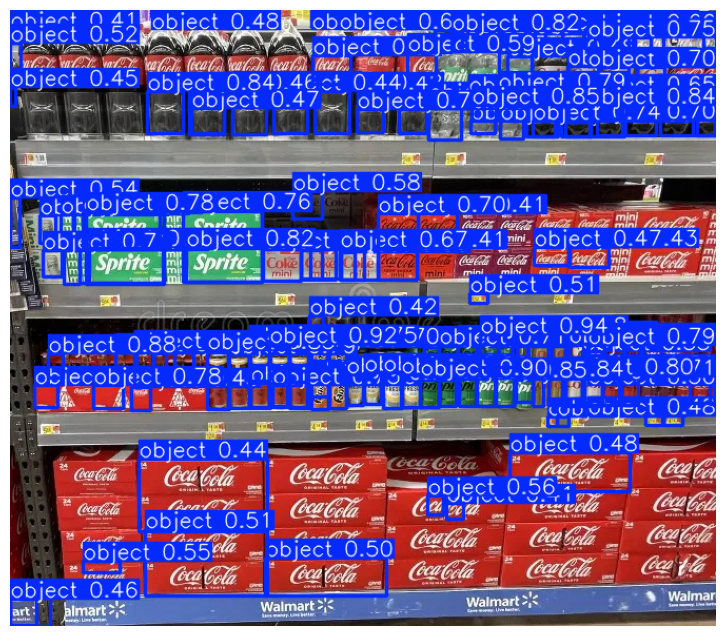

In [63]:
conteo = mostrar_conteos(model, RUTA_TST + rutas_imgs[1],num_umbral=0.4) #con boxes duplicados


Productos detectados:
object: 14


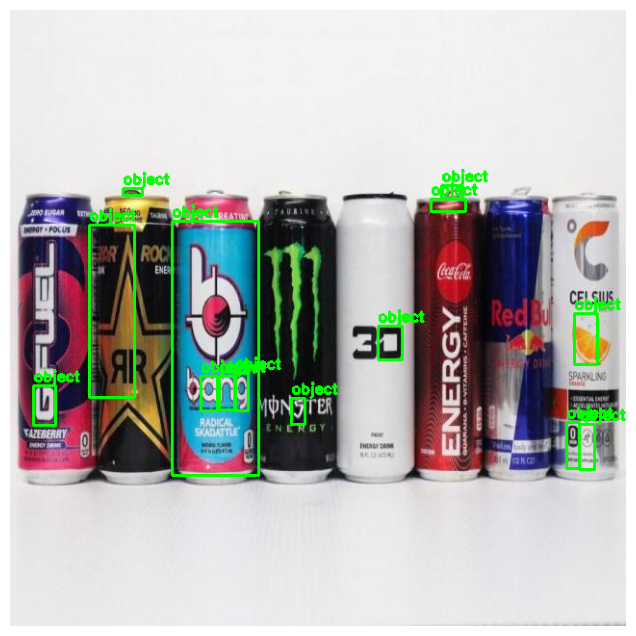

In [68]:
conteo = mostrar_productos_detectados(model, RUTA_TST + rutas_imgs[0],num_umbral=0.4) #quitando boxes duplicados

In [53]:
def eliminar_boxes_duplicados(boxes, iou_threshold=0.5):

    boxes_filtrados = []

    for box in boxes:

        x1, y1, x2, y2 = box.xyxy[0]
        area1 = (x2-x1) * (y2-y1)

        duplicado = False

        for f in boxes_filtrados:

            fx1, fy1, fx2, fy2 = f.xyxy[0]

            inter_x1 = max(x1, fx1)
            inter_y1 = max(y1, fy1)
            inter_x2 = min(x2, fx2)
            inter_y2 = min(y2, fy2)

            inter_area = max(0, inter_x2-inter_x1) * max(0, inter_y2-inter_y1)

            area2 = (fx2-fx1) * (fy2-fy1)

            iou = inter_area / (area1 + area2 - inter_area + 1e-6)

            if iou > iou_threshold:
                duplicado = True
                break

        if not duplicado:
            boxes_filtrados.append(box)

    return boxes_filtrados

In [58]:
def mostrar_productos_detectados(model, img_path,num_umbral):

    # Ejecutar detección
    results = model.predict(
        img_path,
        imgsz=1280,
        conf=num_umbral,
        iou=0.65,
        verbose=False
    )

    boxes = results[0].boxes
    boxes_filtrados = eliminar_boxes_duplicados(boxes)

    img = cv2.imread(img_path)

    productos = []
    nombres = model.names
    for box in boxes_filtrados:

        x1,y1,x2,y2 = map(int, box.xyxy[0])
        conf = float(box.conf)
        cls = int(box.cls)
        label = model.names[cls]

        producto = nombres[cls]
        productos.append(producto)

        etiqueta = f"{producto} {conf:.2f}"

        cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
        cv2.putText(img,label,(x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

    plt.figure(figsize=(12,8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")


    # conteo de productos
    conteo = Counter(productos)

    print("\nProductos detectados:")
    for producto, cantidad in conteo.items():
        print(f"{producto}: {cantidad}")

    return conteo